# Depth vs execution time (search complexity scaling)

## Goal

Measure how the execution time of the engine's **naive min-max search** —
`search.search` / `search._min_max` (connect6/search.py), no pruning, fixed depth cutoff —
scales with the search depth, the key complexity parameter exposed by the engine's
`depth d` command (default 3).

## Expected behaviour

The search explores `MAX_CANDIDATE_MOVES = 30` candidates at every node and performs no
pruning, so the tree for depth `d` contains

```
N(d) = 30^0 + 30^1 + ... + 30^d = (30^(d+1) - 1) / 29     nodes
```

and the time should follow `T(d) ≈ c · N(d)`, multiplying by ≈ 30 for every extra depth —
exponential `O(B^depth)` complexity.

## Benchmark

The position is a fixed mid-game board — ten alternating stones clustered around the centre.
A mid-game board matters because both per-node costs are position-dependent: the evaluation
sweeps all cells and candidate generation scores every cell adjacent to a stone.

Each depth is measured **once**, with a fresh node counter; `search` copies the board
internally before mutating it. At these scales the run-to-run noise is negligible next to the ×30 growth
per depth, so averaging or best-of-N sampling would add nothing. Depth 4 (~1 minute) is the
last measurable point; depth 5 (~25M nodes, half an hour) is extrapolated from the model.

In [1]:
import time

from connect6.board import init_board
from connect6.defines import GRID_NUM, MAX_CANDIDATE_MOVES, Color, Move, Position, SearchStats
from connect6.search import search

DEPTHS = [1, 2, 3, 4]
BRANCHING = MAX_CANDIDATE_MOVES


def create_benchmark_board():
    board = [[0] * GRID_NUM for _ in range(GRID_NUM)]
    init_board(board)
    stones = [
        (10, 10), (11, 10), (9, 11), (11, 9), (8, 12),
        (12, 8), (9, 9), (12, 11), (10, 12), (13, 9),
    ]
    for i, (x, y) in enumerate(stones):
        board[x][y] = Color.BLACK if i % 2 == 0 else Color.WHITE
    return board


def make_last_move(x, y):
    return Move((Position(x, y), Position(x, y)))


def measure_depth(depth):
    stats = SearchStats()
    board = create_benchmark_board()
    start = time.perf_counter()
    search(board, Color.BLACK, depth, make_last_move(13, 9), stats)
    return (time.perf_counter() - start) * 1000, stats.node_count


results = [measure_depth(depth) for depth in DEPTHS]
times_ms = [t for t, _ in results]
node_counts = [n for _, n in results]

print("| depth | time (ms) | nodes   | growth x")
print("|-------|-----------|---------|---------|")
previous = None
for depth, ms, n in zip(DEPTHS, times_ms, node_counts):
    growth = "-" if previous is None else f"{ms / previous:.1f}"
    previous = ms
    print(f"| {depth} | {ms:.1f} | {n} | {growth} |")

| depth | time (ms) | nodes   | growth x
|-------|-----------|---------|---------|
| 1 | 2.1 | 31 | - |
| 2 | 58.4 | 931 | 28.3 |
| 3 | 1788.6 | 27931 | 30.6 |
| 4 | 57487.7 | 829891 | 32.1 |


## Charts

The **theoretical curve** is derived from the measurements themselves: the per-node cost `c`
is estimated as `c = time(depth 1) / nodes(depth 1)`, and the model is then
`T(d) = c · Σ B^k` for `k = 0..d` with `B = MAX_CANDIDATE_MOVES`. If the search is truly
`O(B^depth)`, the measured points will sit on this curve.

- **Left — linear scale:** how the cost explodes in absolute terms, from milliseconds to a
  minute. This is the practical answer to "what does one extra depth cost?".
- **Right — logarithmic scale:** the exponential signature. An exponential function is a
  *straight line* on a log axis; the measured slope must match the theoretical line's slope `B`.

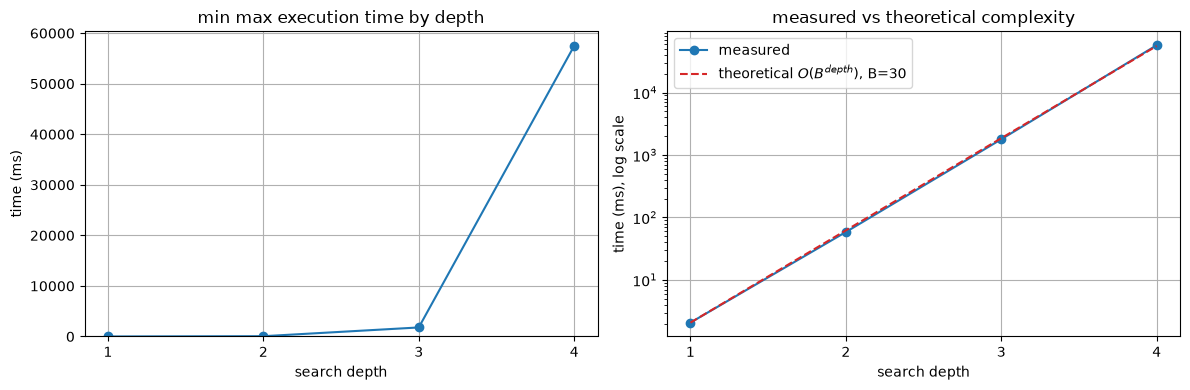

In [2]:
import matplotlib.pyplot as plt

node_cost_ms = times_ms[0] / node_counts[0]
predicted_ms = [node_cost_ms * sum(BRANCHING ** k for k in range(d + 1)) for d in DEPTHS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(DEPTHS, times_ms, marker="o", color="tab:blue")
ax1.set_xlabel("search depth")
ax1.set_ylabel("time (ms)")
ax1.set_title("min max execution time by depth")
ax1.set_xticks(DEPTHS)
ax1.set_ylim(bottom=0)
ax1.grid(True)

ax2.semilogy(DEPTHS, times_ms, marker="o", color="tab:blue", label="measured")
ax2.semilogy(DEPTHS, predicted_ms, linestyle="--", color="tab:red", label=f"theoretical $O(B^{{depth}})$, B={BRANCHING}")
ax2.set_xlabel("search depth")
ax2.set_ylabel("time (ms), log scale")
ax2.set_title("measured vs theoretical complexity")
ax2.set_xticks(DEPTHS)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reading the results

1. **The growth factor converges to ≈ 30** — the table's growth column approaches the engine's
   branching factor. Each additional depth multiplies the tree by `MAX_CANDIDATE_MOVES`; this
   is `O(B^depth)` complexity, confirmed empirically on the real implementation.
2. **The measured curve sits on the theoretical line** — on the log chart the blue points lie on
   the red dashed prediction computed from the per-node cost alone. The model
   `T(d) = c · Σ B^k` fully explains the measured times.
3. **What one node costs** — roughly six hundredths of a millisecond (≈ 15 000 nodes per second),
   dominated by one full `evaluate` sweep (terminal check + living-set counting) plus one
   candidate generation per visited node.
4. **Projection beyond depth 4** — the model extrapolates directly: depth 5 ≈ 30 minutes,
   depth 6 ≈ 15 hours. This is why the engine's default depth is 3, and why plain min-max is
   only playable at `depth 2`-`4`.
5. **The fix is pruning, not tuning** — alpha-beta pruning explores the same best move but cuts
   the effective branching roughly to `√B ≈ 5.5` with good move ordering, turning deep lookahead
   (depth 5-6) from hours into seconds. That is the natural next optimization step.
6. **Search depth is the engine's strength/cost dial** — every extra ply buys lookahead at a
   multiplicative price; the `depth d` command (default 3) exposes exactly this trade-off.